# 07 Bulk RNA-seq

Load Von Hoesslin bulk RNA-seq tables for DP and DN d0 NR, d2 OVA, and d8 OVA. Use editable candidate genes to visualize DESeq2-style size-factor-normalized expression over the time course.

In [53]:
import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-kallies")

sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter
import numpy as np
import pandas as pd

from src.paths import RESULTS_DIR

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 220


In [54]:
von_repo = Path("/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022")
table_dir = von_repo / "results" / "tables"
deseq_dir = table_dir / "02_deseq"

metadata_file = table_dir / "00_loading" / "00_sample_metadata.tsv"
count_file = von_repo / "count matrix" / "GSE208097_count_matrix_compiled"
existing_normalized_file = table_dir / "03_downstream" / "05_gene_barplots" / "05_selected_gene_normalized_expression.tsv"

contrast_files = {
    "DP": {
        "d2 OVA vs d0 NR": deseq_dir / "02_DP_d2_ova_vs_d0_nr_results.tsv",
        "d8 OVA vs d0 NR": deseq_dir / "02_DP_d8_ova_vs_d0_nr_results.tsv",
    },
    "DN": {
        "d2 OVA vs d0 NR": deseq_dir / "02_DN_d2_ova_vs_d0_nr_results.tsv",
        "d8 OVA vs d0 NR": deseq_dir / "02_DN_d8_ova_vs_d0_nr_results.tsv",
    },
}

output_dir = RESULTS_DIR / "07_bulk_rnaseq"
output_dir.mkdir(parents=True, exist_ok=True)

contrast_files, metadata_file, count_file, existing_normalized_file, output_dir


({'DP': {'d2 OVA vs d0 NR': PosixPath('/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022/results/tables/02_deseq/02_DP_d2_ova_vs_d0_nr_results.tsv'),
   'd8 OVA vs d0 NR': PosixPath('/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022/results/tables/02_deseq/02_DP_d8_ova_vs_d0_nr_results.tsv')},
  'DN': {'d2 OVA vs d0 NR': PosixPath('/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022/results/tables/02_deseq/02_DN_d2_ova_vs_d0_nr_results.tsv'),
   'd8 OVA vs d0 NR': PosixPath('/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022/results/tables/02_deseq/02_DN_d8_ova_vs_d0_nr_results.tsv')}},
 PosixPath('/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022/results/tables/00_loading/00_sample_metadata.tsv'),
 PosixPath('/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022/count matrix/GSE208097_count_matrix_compiled'),
 PosixPath('/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022/results/tables/03_

## Load and Merge DESeq2 Tables

In [55]:
de_frames = []
for population, files in contrast_files.items():
    for contrast_label, path in files.items():
        df = pd.read_csv(path, sep="	")
        df = df.copy()
        df["population"] = population
        df["contrast_label"] = contrast_label
        df["timepoint"] = contrast_label.split()[0]
        de_frames.append(df)

de_long = pd.concat(de_frames, ignore_index=True)
de_long = de_long[
    [
        "gene_id",
        "gene_name",
        "population",
        "timepoint",
        "contrast_label",
        "baseMean",
        "log2FoldChange",
        "lfcSE",
        "pvalue",
        "padj",
        "significant",
    ]
].copy()

merged_de = de_long.pivot_table(
    index=["gene_id", "gene_name"],
    columns=["population", "timepoint"],
    values=["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "significant"],
    aggfunc="first",
)
merged_de.columns = [f"{pop}_{time}_{stat}" for stat, pop, time in merged_de.columns]
merged_de = merged_de.reset_index()

long_de_file = output_dir / "07_bulk_rnaseq_DP_DN_d2_d8_ova_vs_d0_nr_deseq_long.tsv"
merged_de_file = output_dir / "07_bulk_rnaseq_DP_DN_d2_d8_ova_vs_d0_nr_merged_deseq.tsv"
de_long.to_csv(long_de_file, sep="	", index=False)
merged_de.to_csv(merged_de_file, sep="	", index=False)
print("Saved:", long_de_file)
print("Saved:", merged_de_file)
merged_de.head()


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DP_DN_d2_d8_ova_vs_d0_nr_deseq_long.tsv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DP_DN_d2_d8_ova_vs_d0_nr_merged_deseq.tsv


,gene_id,gene_name,DN_d2_baseMean,DN_d8_baseMean,DP_d2_baseMean,DP_d8_baseMean,DN_d2_lfcSE,DN_d8_lfcSE,DP_d2_lfcSE,DP_d8_lfcSE,...,DP_d2_padj,DP_d8_padj,DN_d2_pvalue,DN_d8_pvalue,DP_d2_pvalue,DP_d8_pvalue,DN_d2_significant,DN_d8_significant,DP_d2_significant,DP_d8_significant
0,ENSMUSG00000000001,Gnai3,5238.609335,4256.587302,4290.288496,1412.548575,0.144963,0.336413,0.154251,0.554826,...,0.974614,0.005013,0.002105,0.000105,0.894454,0.000194,False,True,False,True
1,ENSMUSG00000000028,Cdc45,135.567971,82.959942,89.427799,29.748019,0.429091,0.463700,0.969355,0.671318,...,0.662007,0.935924,0.231850,0.904237,0.331036,0.825939,False,False,False,False
2,ENSMUSG00000000049,Apoh,4.388175,1.336383,6.397172,0.316320,0.410240,0.582113,1.313337,0.679635,...,0.226850,NaN,0.320562,0.941124,0.054106,0.737726,False,False,False,False
3,ENSMUSG00000000056,Narf,1049.437359,923.483388,1069.382923,571.911946,0.169310,0.271922,0.162326,0.457413,...,0.847931,0.983934,0.652614,0.154841,0.572176,0.952476,False,False,False,False
4,ENSMUSG00000000058,Cav2,6.905899,8.679808,43.173026,5.618840,0.410920,0.600943,1.586927,0.697599,...,0.000079,0.421407,0.068600,0.043480,0.000004,0.153135,False,False,True,False


## Candidate Genes

In [81]:
# Edit this list to change which genes are plotted.
candidate_genes = [
    # Core egress / recirculation
    "Klf2",
    "S1pr1",
    "S1pr5",
    "Ccr7",
    "Sell",
    "Selplg",
    "Tcf7",
    "Lef1",
    "Foxo1",
    "Il7r",
    "Bach2",
    "Bcl2",
    "Klf3",
    "Klf6",
    "Cxcr4",
    "Cx3cr1",
    "Cxcr3",
    "Ccr5",
    "Ccr6",
    "Ccr9",
    "Cxcr5",
    "Itgb7",
    "Itga4",
    "Id3",
    "Eomes",
    "Slamf6",
    "Ly6c2",

    # Core residency / retention
    "Cd69",
    "Itgae",
    "Itga1",
    "Cxcr6",
    "Runx3",
    "Prdm1",
    "Zfp683",
    "Ahr",
    "Bhlhe40",
    "Rgs1",
    "Rgs2",
    "Rgs10",
    "Rgs16",
    "Nr4a1",
    "Nr4a2",
    "Nr4a3",
    "Id2",
    "Tox",
    "Tox2",
    "Batf",
    "Irf4",
    "Notch1",
    "Notch2",
    "Rbpj",
    "Hif1a",

    # TGFβ signaling
    "Tgfbr1",
    "Tgfbr2",
    "Tgfbr3",
    "Smad2",
    "Smad3",
    "Smad4",
    "Skil",

    # Cytokine / survival
    "Il2rb",
    "Il15ra",
    "Il18r1",
    "Il18rap",
    "Il12rb1",
    "Il12rb2",

    # Activation / transition
    "Fos",
    "Fosb",
    "Fosl2",
    "Jun",
    "Junb",
    "Jund",
    "Egr1",
    "Egr2",
    "Egr3",
    "Dusp1",
    "Dusp2",
    "Dusp4",
    "Dusp5",
    "Dusp6",
    "Ier2",
    "Ier3",
    "Nfkbia",
    "Nfkbiz",
    "Tnfaip3",
    "Zfp36",
    "Zfp36l1",
    "Zfp36l2",
    "Socs1",
    "Socs3",

    # Chemokines / recruitment
    "Xcl1",
    "Xcl2",
    "Ccl1",
    "Ccl3",
    "Ccl4",
    "Ccl5",
    "Ccl9",

    # Effector / recall response
    "Ifng",
    "Tnf",
    "Lta",
    "Gzma",
    "Gzmb",
    "Gzmc",
    "Gzmk",
    "Prf1",
    "Nkg7",
    "Ctsw",
    "Fasl",

    # Checkpoint / costimulation
    "Pdcd1",
    "Tigit",
    "Ctla4",
    "Lag3",
    "Havcr2",
    "Entpd1",
    "Lair1",
    "Icos",
    "Tnfrsf4",
    "Tnfrsf9",
    "Tnfrsf18",
    "Cd27",
    "Cd28",
    "Cd40lg",
    "Cd101",
    "Cd160",
    "Cd244a",
    "Klrc1",
    "Klrc2",
    "Klrg1",

    # Interferon / antiviral
    "Isg15",
    "Isg20",
    "Ifitm1",
    "Ifitm2",
    "Ifitm3",
    "Ifit1",
    "Ifit2",
    "Ifit3",
    "Irf1",
    "Irf7",
    "Irf8",
    "Irf9",
    "Stat1",
    "Stat2",
    "Mx1",
    "Mx2",
    "Oas1a",
    "Oas1b",
    "Oas1g",
    "Oas2",
    "Oas3",
    "Oasl1",
    "Oasl2",
    "Rsad2",
    "Usp18",
    "Ddx58",
    "Ifih1",
    "Ddx60",
    "Ddx60l",
    "Zbp1",
    "Bst2",
    "Parp9",
    "Parp10",
    "Parp12",
    "Parp14",
    "Samd9l",
    "Sp100",
    "Trim21",
    "Trim25",
    "Trim30a",
    "Trim56",
    "Herc6",
    "Epsti1",
    "Gbp2",
    "Gbp3",
    "Gbp4",
    "Gbp5",
    "Gbp7",
    "Gbp8",

    # Antigen presentation
    "Tap1",
    "Tap2",
    "Psmb8",
    "Psmb9",
    "B2m",
    "H2-K1",
    "H2-D1",
    "H2-Q7",
    "H2-T23",

    # Tissue adaptation / structural
    "Lgals1",
    "Lgals3",
    "Lgals9",
    "Anxa1",
    "Anxa2",
    "S100a4",
    "S100a6",
    "Vim",
    "Capg",
    "Coro1a",
    "Cfl1",
    "Actb",

    # Metabolism
    "Myc",
    "Slc7a5",
    "Slc3a2",
    "Slc2a1",
    "Mtor",
    "Rptor",
    "Eif4ebp1",
    "Ldha",
    "Gapdh",
    "Eno1",
    "Pkm",
    "Aldoa",

    # Proliferation
    "Mki67",
    "Top2a",
    "Pcna",
    "Mcm2",
    "Mcm3",
    "Mcm4",
    "Mcm5",
    "Mcm6",
    "Mcm7",
    "Cdk1",
    "Cdk2",
    "Ccna2",
    "Ccnb1",
    "Ccnb2",
    "Cdc20",
    "Birc5",
    "Stmn1",

    # Your specific candidates
    "Hic1",
    "Glp1r",
    "Nr3c1",
    "Xcr1",
    "Rara"
]

candidate_de = de_long[de_long["gene_name"].isin(candidate_genes)].copy()
candidate_de["gene_name"] = pd.Categorical(candidate_de["gene_name"], categories=candidate_genes, ordered=True)
candidate_de["population"] = pd.Categorical(candidate_de["population"], categories=["DP", "DN"], ordered=True)
candidate_de["timepoint"] = pd.Categorical(candidate_de["timepoint"], categories=["d2", "d8"], ordered=True)
candidate_de = candidate_de.sort_values(["gene_name", "population", "timepoint"])

candidate_de_file = output_dir / "07_bulk_rnaseq_candidate_gene_d2_d8_deseq.tsv"
candidate_de.to_csv(candidate_de_file, sep="	", index=False)
print("Saved:", candidate_de_file)
candidate_de


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_candidate_gene_d2_d8_deseq.tsv


,gene_id,gene_name,population,timepoint,contrast_label,baseMean,log2FoldChange,lfcSE,pvalue,padj,significant
2501,ENSMUSG00000055148,Klf2,DP,d2,d2 OVA vs d0 NR,1017.065092,1.141424,0.552970,0.015527,0.091429,False
28327,ENSMUSG00000055148,Klf2,DP,d8,d8 OVA vs d0 NR,288.223878,0.034547,0.501135,0.926346,0.973039,False
45043,ENSMUSG00000055148,Klf2,DN,d2,d2 OVA vs d0 NR,2486.176248,0.065203,0.191655,0.701987,0.928834,False
60515,ENSMUSG00000055148,Klf2,DN,d8,d8 OVA vs d0 NR,2504.551638,0.153528,0.262147,0.516040,0.713436,False
3148,ENSMUSG00000045092,S1pr1,DP,d2,d2 OVA vs d0 NR,161.901272,1.386001,1.141199,0.038023,0.177894,False
...,...,...,...,...,...,...,...,...,...,...,...
53965,ENSMUSG00000060509,Xcr1,DN,d8,d8 OVA vs d0 NR,314.032786,0.637887,0.326305,0.021988,0.094492,False
13466,ENSMUSG00000037992,Rara,DP,d2,d2 OVA vs d0 NR,129.490424,0.058232,0.474394,0.891504,0.973855,False
25444,ENSMUSG00000037992,Rara,DP,d8,d8 OVA vs d0 NR,58.471119,-0.193246,0.472018,0.576767,0.811340,False
48221,ENSMUSG00000037992,Rara,DN,d2,d2 OVA vs d0 NR,285.674128,-0.007899,0.275750,0.966067,0.992696,False


## Candidate Gene padj Summary

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_candidate_gene_padj_summary.tsv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_candidate_gene_padj_heatmap.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_candidate_gene_padj_heatmap.pdf


contrast,gene_name,DP d2 vs d0,DP d8 vs d0,DN d2 vs d0,DN d8 vs d0
0,Klf2,9.142918e-02,0.973039,0.928834,0.713436
1,S1pr1,1.778941e-01,0.797256,0.013820,0.792989
2,S1pr5,NaN,NaN,0.910136,0.348963
3,Ccr7,1.795127e-26,0.937560,0.822739,0.268787
4,Sell,1.082033e-06,NaN,0.897546,0.000056
...,...,...,...,...,...
224,Hic1,9.177080e-01,0.000069,0.635961,0.004739
225,Glp1r,9.886595e-01,0.029360,0.001579,NaN
226,Nr3c1,1.414780e-01,0.822139,0.297775,0.440187
227,Xcr1,9.944500e-01,0.781194,0.604325,0.094492


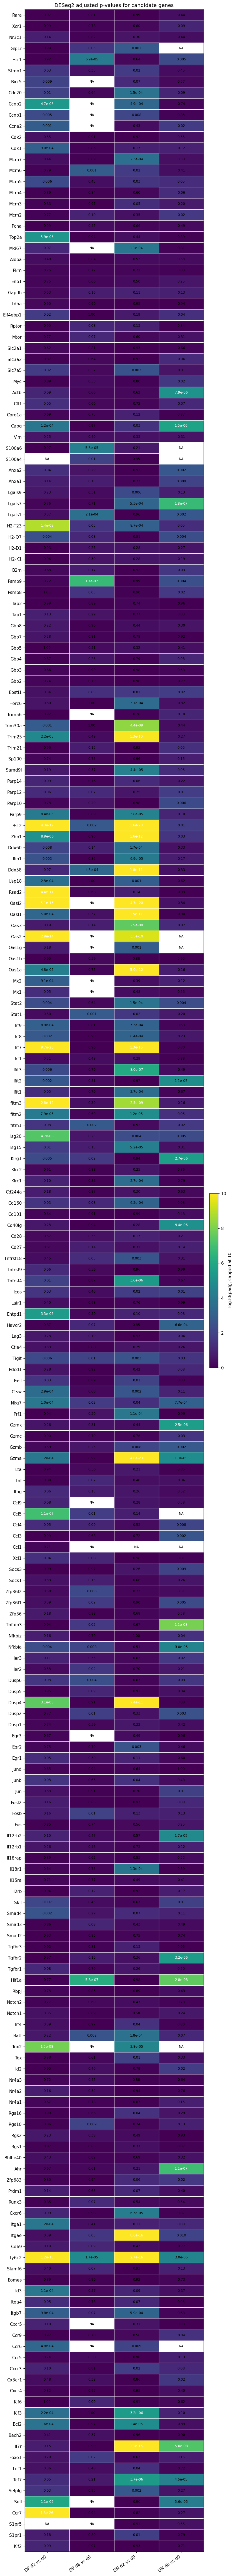

In [82]:
def format_padj(value):
    if pd.isna(value):
        return "NA"
    if value < 0.001:
        return f"{value:.1e}"
    if value < 0.01:
        return f"{value:.3f}"
    return f"{value:.2f}"


padj_summary = candidate_de.copy()
padj_summary["contrast"] = padj_summary["population"].astype(str) + " " + padj_summary["timepoint"].astype(str) + " vs d0"
padj_columns = ["DP d2 vs d0", "DP d8 vs d0", "DN d2 vs d0", "DN d8 vs d0"]
padj_genes = [gene for gene in candidate_genes if gene in set(candidate_de["gene_name"].astype(str))]

padj_matrix = (
    padj_summary.pivot(index="gene_name", columns="contrast", values="padj")
    .reindex(index=padj_genes, columns=padj_columns)
)
neg_log10_padj = -np.log10(padj_matrix.clip(lower=np.nextafter(0, 1)))
neg_log10_padj = neg_log10_padj.clip(upper=10)

padj_table = padj_matrix.reset_index()
padj_table_file = output_dir / "07_bulk_rnaseq_candidate_gene_padj_summary.tsv"
padj_table.to_csv(padj_table_file, sep="	", index=False)
print("Saved:", padj_table_file)

fig_width = max(6.8, 1.25 * len(padj_columns) + 2.8)
fig_height = max(5.2, 0.36 * len(padj_genes) + 1.8)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

plot_values = neg_log10_padj.reindex(index=list(reversed(padj_genes))).values
image = ax.imshow(plot_values, cmap="viridis", aspect="auto", vmin=0, vmax=10)

ax.set_xticks(np.arange(len(padj_columns)))
ax.set_xticklabels(padj_columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(padj_genes)))
ax.set_yticklabels(list(reversed(padj_genes)))
ax.set_title("DESeq2 adjusted p-values for candidate genes")

for y, gene in enumerate(reversed(padj_genes)):
    for x, contrast in enumerate(padj_columns):
        value = padj_matrix.loc[gene, contrast]
        label = format_padj(value)
        text_color = "white" if pd.notna(value) and neg_log10_padj.loc[gene, contrast] > 5 else "black"
        ax.text(x, y, label, ha="center", va="center", fontsize=8, color=text_color)

for x in np.arange(-0.5, len(padj_columns), 1):
    ax.axvline(x, color="white", linewidth=0.8)
for y in np.arange(-0.5, len(padj_genes), 1):
    ax.axhline(y, color="white", linewidth=0.8)

cbar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("-log10(padj), capped at 10")
fig.tight_layout()

padj_png = output_dir / "07_bulk_rnaseq_candidate_gene_padj_heatmap.png"
padj_pdf = output_dir / "07_bulk_rnaseq_candidate_gene_padj_heatmap.pdf"
fig.savefig(padj_png, bbox_inches="tight")
fig.savefig(padj_pdf, bbox_inches="tight")
print("Saved:", padj_png)
print("Saved:", padj_pdf)
padj_table


## DESeq2-Normalized Expression for d0, d2 OVA, and d8 OVA Samples

In [83]:
condition_map = {
    "DP_nr_d0": "d0 NR",
    "DP_ova_d2": "d2 OVA",
    "DP_ova_d8": "d8 OVA",
    "DN_nr_d0": "d0 NR",
    "DN_ova_d2": "d2 OVA",
    "DN_ova_d8": "d8 OVA",
}
condition_order = ["d0 NR", "d2 OVA", "d8 OVA"]

all_metadata = pd.read_csv(metadata_file, sep="	")
plot_metadata = all_metadata[all_metadata["condition"].isin(condition_map)].copy()
plot_metadata["population"] = plot_metadata["subpopulation"]
plot_metadata["time_condition"] = plot_metadata["condition"].map(condition_map)
plot_metadata["time_condition"] = pd.Categorical(plot_metadata["time_condition"], categories=condition_order, ordered=True)

counts = pd.read_csv(count_file, sep="	")
all_sample_cols = all_metadata["sample_id"].tolist()
count_matrix = counts.set_index("gene_name")[all_sample_cols].groupby(level=0).sum()

present_genes = [gene for gene in candidate_genes if gene in count_matrix.index]
missing_genes = sorted(set(candidate_genes).difference(present_genes))
print("Present genes:", present_genes)
print("Missing genes:", missing_genes)

if not present_genes:
    raise ValueError("None of the candidate genes were found in the count matrix.")

# Match the Von Hoesslin R notebook: DESeqDataSetFromMatrix(..., design = ~ 1),
# estimateSizeFactors(dds), then counts(dds, normalized = TRUE). Size factors are
# estimated on all samples, then the d0/d2/d8 OVA samples are selected for plotting.
positive_counts = count_matrix[count_matrix.gt(0).all(axis=1)]
if positive_counts.empty:
    raise ValueError("No genes have positive counts in every sample for median-ratio size-factor estimation.")
log_geomeans = np.log(positive_counts).mean(axis=1)
geomeans = np.exp(log_geomeans)
ratios = positive_counts.div(geomeans, axis=0)
size_factors = ratios.median(axis=0)

normalized_counts = count_matrix.div(size_factors, axis=1)
plot_sample_cols = plot_metadata["sample_id"].tolist()
candidate_normalized = normalized_counts.loc[present_genes, plot_sample_cols]

expr_long = (
    candidate_normalized.reset_index(names="gene_name")
    .melt(id_vars="gene_name", var_name="sample_id", value_name="deseq_normalized_count")
    .merge(plot_metadata, on="sample_id", how="left")
)
expr_long["plot_expression"] = expr_long["deseq_normalized_count"] + 1
expr_long["gene_name"] = pd.Categorical(expr_long["gene_name"], categories=present_genes, ordered=True)
expr_long["population"] = pd.Categorical(expr_long["population"], categories=["DP", "DN"], ordered=True)

size_factor_file = output_dir / "07_bulk_rnaseq_deseq_size_factors_all_samples.tsv"
pd.DataFrame({"sample_id": size_factors.index, "size_factor": size_factors.values}).to_csv(size_factor_file, sep="	", index=False)

expr_file = output_dir / "07_bulk_rnaseq_candidate_gene_deseq_normalized_counts_by_sample_d0_d2_d8.tsv"
expr_long.to_csv(expr_file, sep="	", index=False)
print("Saved:", size_factor_file)
print("Saved:", expr_file)
expr_long.head()


Present genes: ['Klf2', 'S1pr1', 'S1pr5', 'Ccr7', 'Sell', 'Selplg', 'Tcf7', 'Lef1', 'Foxo1', 'Il7r', 'Bach2', 'Bcl2', 'Klf3', 'Klf6', 'Cxcr4', 'Cx3cr1', 'Cxcr3', 'Ccr5', 'Ccr6', 'Ccr9', 'Cxcr5', 'Itgb7', 'Itga4', 'Id3', 'Eomes', 'Slamf6', 'Ly6c2', 'Cd69', 'Itgae', 'Itga1', 'Cxcr6', 'Runx3', 'Prdm1', 'Zfp683', 'Ahr', 'Bhlhe40', 'Rgs1', 'Rgs2', 'Rgs10', 'Rgs16', 'Nr4a1', 'Nr4a2', 'Nr4a3', 'Id2', 'Tox', 'Tox2', 'Batf', 'Irf4', 'Notch1', 'Notch2', 'Rbpj', 'Hif1a', 'Tgfbr1', 'Tgfbr2', 'Tgfbr3', 'Smad2', 'Smad3', 'Smad4', 'Skil', 'Il2rb', 'Il15ra', 'Il18r1', 'Il18rap', 'Il12rb1', 'Il12rb2', 'Fos', 'Fosb', 'Fosl2', 'Jun', 'Junb', 'Jund', 'Egr1', 'Egr2', 'Egr3', 'Dusp1', 'Dusp2', 'Dusp4', 'Dusp5', 'Dusp6', 'Ier2', 'Ier3', 'Nfkbia', 'Nfkbiz', 'Tnfaip3', 'Zfp36', 'Zfp36l1', 'Zfp36l2', 'Socs1', 'Socs3', 'Xcl1', 'Ccl1', 'Ccl3', 'Ccl4', 'Ccl5', 'Ccl9', 'Ifng', 'Tnf', 'Lta', 'Gzma', 'Gzmb', 'Gzmc', 'Gzmk', 'Prf1', 'Nkg7', 'Ctsw', 'Fasl', 'Pdcd1', 'Tigit', 'Ctla4', 'Lag3', 'Havcr2', 'Entpd1', 'Lair1'

,gene_name,sample_id,deseq_normalized_count,geo_accession,raw_column,batch,subpopulation,group_code,timepoint,replicate,condition,population,time_condition,plot_expression
0,Klf2,DP_nr_d0_1,171.692685,GSM6337029,L1_S1,A,DP,nr,d0,1,DP_nr_d0,DP,d0 NR,172.692685
1,S1pr1,DP_nr_d0_1,68.885819,GSM6337029,L1_S1,A,DP,nr,d0,1,DP_nr_d0,DP,d0 NR,69.885819
2,S1pr5,DP_nr_d0_1,0.000000,GSM6337029,L1_S1,A,DP,nr,d0,1,DP_nr_d0,DP,d0 NR,1.000000
3,Ccr7,DP_nr_d0_1,22.440077,GSM6337029,L1_S1,A,DP,nr,d0,1,DP_nr_d0,DP,d0 NR,23.440077
4,Sell,DP_nr_d0_1,0.521862,GSM6337029,L1_S1,A,DP,nr,d0,1,DP_nr_d0,DP,d0 NR,1.521862


In [58]:
existing_normalized = pd.read_csv(existing_normalized_file, sep="	")
validation = existing_normalized.merge(
    normalized_counts.stack().rename("python_normalized_count").reset_index().rename(columns={"level_0": "gene_name", "level_1": "sample_id"}),
    on=["gene_name", "sample_id"],
    how="inner",
)
validation["abs_difference"] = (validation["normalized_expression"] - validation["python_normalized_count"]).abs()
validation_summary = pd.DataFrame(
    {
        "n_values_compared": [len(validation)],
        "max_abs_difference": [validation["abs_difference"].max()],
        "median_abs_difference": [validation["abs_difference"].median()],
    }
)
validation_file = output_dir / "07_bulk_rnaseq_deseq_normalization_validation_against_existing_table.tsv"
validation_summary.to_csv(validation_file, sep="	", index=False)
print("Saved:", validation_file)
validation_summary


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_deseq_normalization_validation_against_existing_table.tsv


,n_values_compared,max_abs_difference,median_abs_difference
0,60,0.000051,4.813072e-07


In [59]:
expr_summary = (
    expr_long.groupby(["gene_name", "population", "time_condition"], observed=True)["deseq_normalized_count"]
    .agg(mean="mean", sd="std", n="size")
    .reset_index()
)
expr_summary["sem"] = expr_summary["sd"] / np.sqrt(expr_summary["n"])
expr_summary["plot_mean"] = expr_summary["mean"] + 1
expr_summary["plot_lower"] = np.maximum(expr_summary["mean"] - expr_summary["sem"], 0) + 1
expr_summary["plot_upper"] = expr_summary["mean"] + expr_summary["sem"] + 1

summary_file = output_dir / "07_bulk_rnaseq_candidate_gene_deseq_normalized_count_summary_d0_d2_d8.tsv"
expr_summary.to_csv(summary_file, sep="	", index=False)
print("Saved:", summary_file)
expr_summary


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_candidate_gene_deseq_normalized_count_summary_d0_d2_d8.tsv


,gene_name,population,time_condition,mean,sd,n,sem,plot_mean,plot_lower,plot_upper
0,Ccr7,DP,d0 NR,12.484005,9.289989,3,5.363578,13.484005,8.120427,18.847583
1,Ccr7,DP,d2 OVA,671.719052,144.958827,4,72.479414,672.719052,600.239638,745.198465
2,Ccr7,DP,d8 OVA,8.902836,15.420165,3,8.902836,9.902836,1.000000,18.805673
3,Ccr7,DN,d0 NR,923.170967,639.675596,3,369.316877,924.170967,554.854089,1293.487844
4,Ccr7,DN,d2 OVA,1329.291533,599.975449,4,299.987724,1330.291533,1030.303809,1630.279258
...,...,...,...,...,...,...,...,...,...,...
85,Rara,DP,d2 OVA,90.998395,23.156188,4,11.578094,91.998395,80.420301,103.576489
86,Rara,DP,d8 OVA,66.603119,8.060875,3,4.653948,67.603119,62.949171,72.257067
87,Rara,DN,d0 NR,204.129372,78.973420,3,45.595325,205.129372,159.534047,250.724697
88,Rara,DN,d2 OVA,210.741226,54.368437,4,27.184218,211.741226,184.557008,238.925445


## Dot Plot of Scaled Candidate Gene Expression

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_candidate_gene_scaled_dotplot_values_by_population.tsv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DP_candidate_gene_scaled_dotplot_d0_d2_d8.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DP_candidate_gene_scaled_dotplot_d0_d2_d8.pdf
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DN_candidate_gene_scaled_dotplot_d0_d2_d8.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DN_candidate_gene_scaled_dotplot_d0_d2_d8.pdf


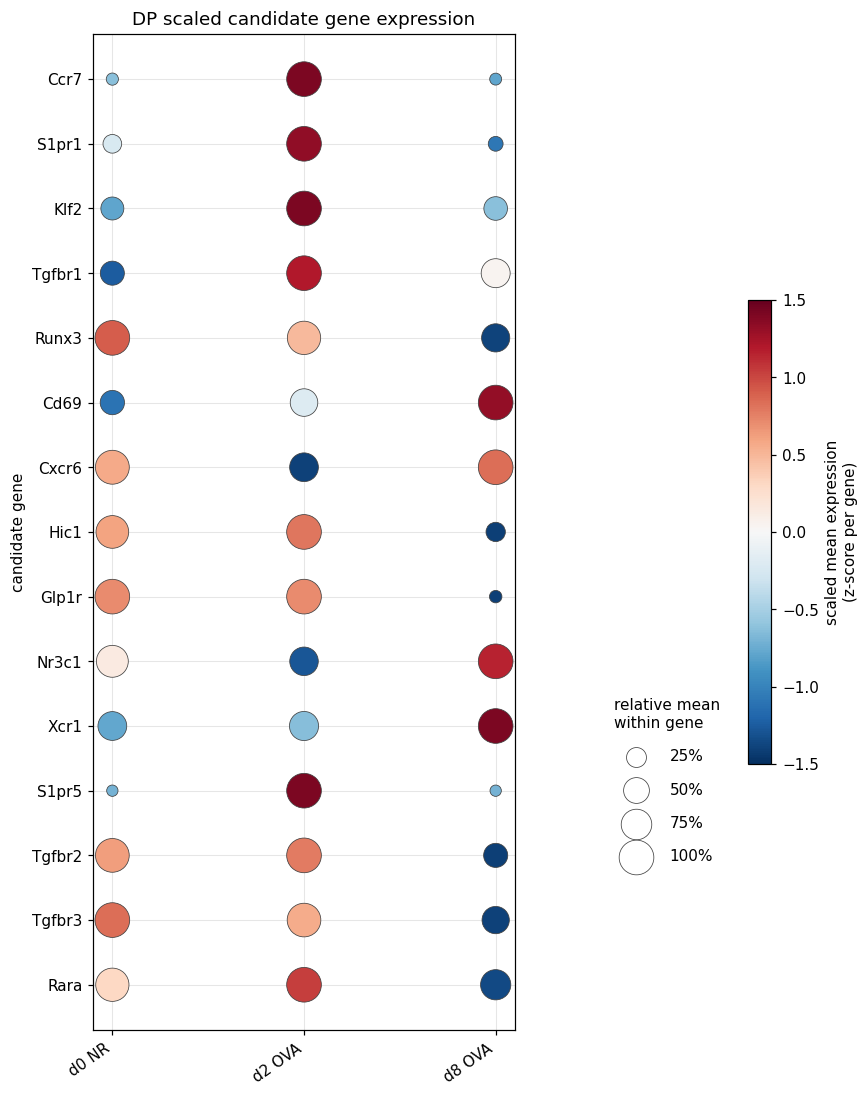

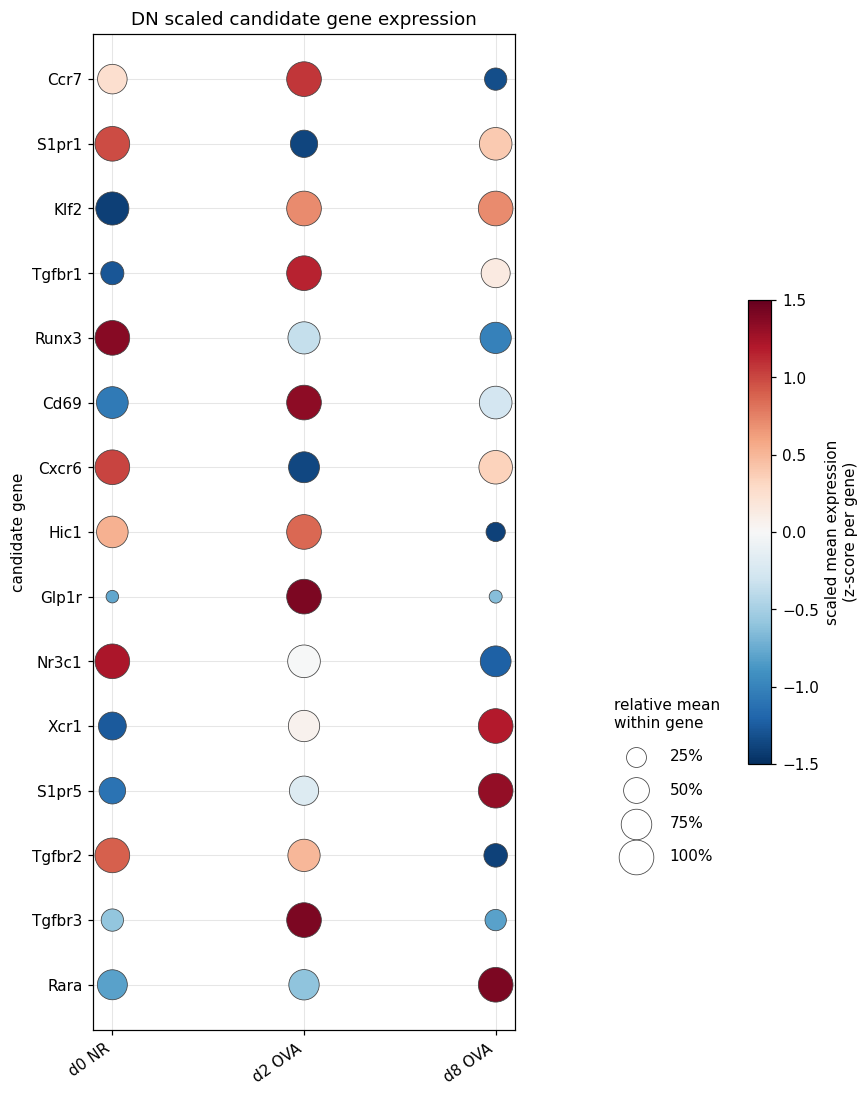

In [64]:
# Scale each gene separately within each population, across d0/d2/d8.
dot_summary = expr_summary.copy()
dot_summary["log10_mean_plus_1"] = np.log10(dot_summary["mean"] + 1)
dot_summary["scaled_expression"] = dot_summary.groupby(["population", "gene_name"], observed=True)["log10_mean_plus_1"].transform(
    lambda values: (values - values.mean()) / values.std(ddof=0) if values.std(ddof=0) > 0 else 0
)
dot_summary["relative_mean"] = dot_summary.groupby(["population", "gene_name"], observed=True)["mean"].transform(
    lambda values: values / values.max() if values.max() > 0 else 0
)

dot_summary["gene_name"] = pd.Categorical(dot_summary["gene_name"].astype(str), categories=present_genes, ordered=True)
dot_summary["time_condition"] = pd.Categorical(dot_summary["time_condition"].astype(str), categories=condition_order, ordered=True)
dot_summary = dot_summary.sort_values(["population", "gene_name", "time_condition"])

dotplot_table = output_dir / "07_bulk_rnaseq_candidate_gene_scaled_dotplot_values_by_population.tsv"
dot_summary.to_csv(dotplot_table, sep="	", index=False)
print("Saved:", dotplot_table)


def make_population_dotplot(population):
    plot_df = dot_summary[dot_summary["population"].astype(str).eq(population)].copy()
    genes_for_plot = list(reversed(present_genes))
    plot_df["gene_plot"] = pd.Categorical(plot_df["gene_name"].astype(str), categories=genes_for_plot, ordered=True)
    plot_df["x"] = plot_df["time_condition"].cat.codes
    plot_df["y"] = plot_df["gene_plot"].cat.codes

    fig_width = 7.8
    fig_height = max(5.3, 0.55 * len(present_genes) + 1.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

    sizes = 55 + 460 * plot_df["relative_mean"].fillna(0)
    scatter = ax.scatter(
        plot_df["x"],
        plot_df["y"],
        s=sizes,
        c=plot_df["scaled_expression"],
        cmap="RdBu_r",
        vmin=-1.5,
        vmax=1.5,
        edgecolor="0.25",
        linewidth=0.5,
    )

    ax.set_xticks(range(len(condition_order)))
    ax.set_xticklabels(condition_order, rotation=35, ha="right")
    ax.set_yticks(range(len(genes_for_plot)))
    ax.set_yticklabels(genes_for_plot)
    ax.set_ylabel("candidate gene")
    ax.set_title(f"{population} scaled candidate gene expression")
    ax.grid(axis="both", color="0.9", linewidth=0.7)
    ax.set_axisbelow(True)

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.055, pad=0.04)
    cbar.set_label("scaled mean expression\n(z-score per gene)")

    legend_values = [0.25, 0.50, 0.75, 1.00]
    legend_handles = [
    ax.scatter(
        [], [],
        s=55 + 460 * value,
        color="white",
        edgecolor="0.25",
        linewidth=0.5
    )
    for value in legend_values
]
    ax.legend(
        legend_handles,
        [f"{int(value * 100)}%" for value in legend_values],
        title="relative mean\nwithin gene",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.22, 0.25),
        borderaxespad=0,
        labelspacing=1.2,
        handletextpad=1.2,
)

    
    dotplot_png = output_dir / f"07_bulk_rnaseq_{population}_candidate_gene_scaled_dotplot_d0_d2_d8.png"
    dotplot_pdf = output_dir / f"07_bulk_rnaseq_{population}_candidate_gene_scaled_dotplot_d0_d2_d8.pdf"
    fig.savefig(dotplot_png, bbox_inches="tight")
    fig.savefig(dotplot_pdf, bbox_inches="tight")
    print("Saved:", dotplot_png)
    print("Saved:", dotplot_pdf)
    return fig


dp_dotplot = make_population_dotplot("DP")
dn_dotplot = make_population_dotplot("DN")


## Separate DP and DN Time-Course Bar Plots

In [61]:
expression_colors = {
    "d0 NR": "#65c4ed",
    "d2 OVA": "#fdea59",
    "d8 OVA": "#fc7e2b",
}



def plot_population_timecourse(population):
    pop_expr = expr_summary[expr_summary["population"].astype(str).eq(population)].copy()
    pop_samples = expr_long[expr_long["population"].astype(str).eq(population)].copy()

    n_genes = len(present_genes)
    fig, axes = plt.subplots(
        1,
        n_genes,
        figsize=(2.15 * n_genes, 3.4),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, gene in zip(axes, present_genes):
        gene_expr = pop_expr[pop_expr["gene_name"].astype(str).eq(gene)].set_index("time_condition").reindex(condition_order)
        gene_samples = pop_samples[pop_samples["gene_name"].astype(str).eq(gene)]
        x = np.arange(len(condition_order))

        ax.bar(
            x,
            gene_expr["plot_mean"].values,
            yerr=[
                gene_expr["plot_mean"].values - gene_expr["plot_lower"].values,
                gene_expr["plot_upper"].values - gene_expr["plot_mean"].values,
            ],
            width=0.46,
            color=[expression_colors[label] for label in condition_order],
            edgecolor="0.25",
            linewidth=0.7,
            capsize=2,
        )
        for i, condition in enumerate(condition_order):
            values = gene_samples.loc[gene_samples["time_condition"].astype(str).eq(condition), "plot_expression"].to_numpy()
            jitter = np.linspace(-0.055, 0.055, len(values)) if len(values) > 1 else np.array([0])
            ax.scatter(np.full(len(values), i) + jitter, values, color="black", s=12, alpha=0.75, zorder=3)

        ax.set_title(gene)
        ax.set_xticks(x)
        ax.set_xticklabels(condition_order, rotation=40, ha="right")
        ymax = np.nanmax(gene_expr["plot_upper"].values)
        ymax = 10 ** np.ceil(np.log10(max(ymax, 1.0)))
        ax.set_ylim(1, ymax)
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.grid(axis="y", color="0.9", linewidth=0.7, which="both")
        ax.tick_params(axis="y", labelsize=8)
        ax.set_axisbelow(True)
        if ax is axes[0]:
            ax.set_ylabel("DESeq2 normalized counts + 1\n(log scale)")
        else:
            ax.set_ylabel("")

    fig.suptitle(f"{population} candidate marker expression over time", y=1.05)
    fig.tight_layout()

    png = output_dir / f"07_bulk_rnaseq_{population}_candidate_gene_timecourse_deseq_normalized_counts_d0_d2_d8.png"
    pdf = output_dir / f"07_bulk_rnaseq_{population}_candidate_gene_timecourse_deseq_normalized_counts_d0_d2_d8.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)
    return fig


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DP_candidate_gene_timecourse_deseq_normalized_counts_d0_d2_d8.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DP_candidate_gene_timecourse_deseq_normalized_counts_d0_d2_d8.pdf


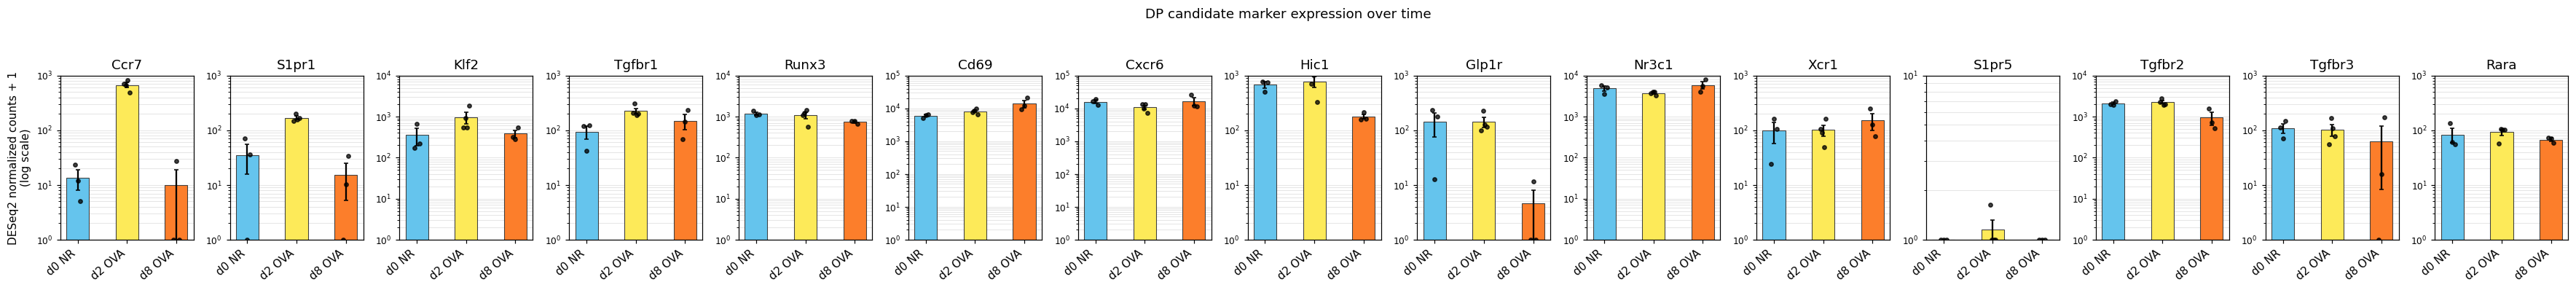

In [62]:
dp_fig = plot_population_timecourse("DP")


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DN_candidate_gene_timecourse_deseq_normalized_counts_d0_d2_d8.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_rnaseq/07_bulk_rnaseq_DN_candidate_gene_timecourse_deseq_normalized_counts_d0_d2_d8.pdf


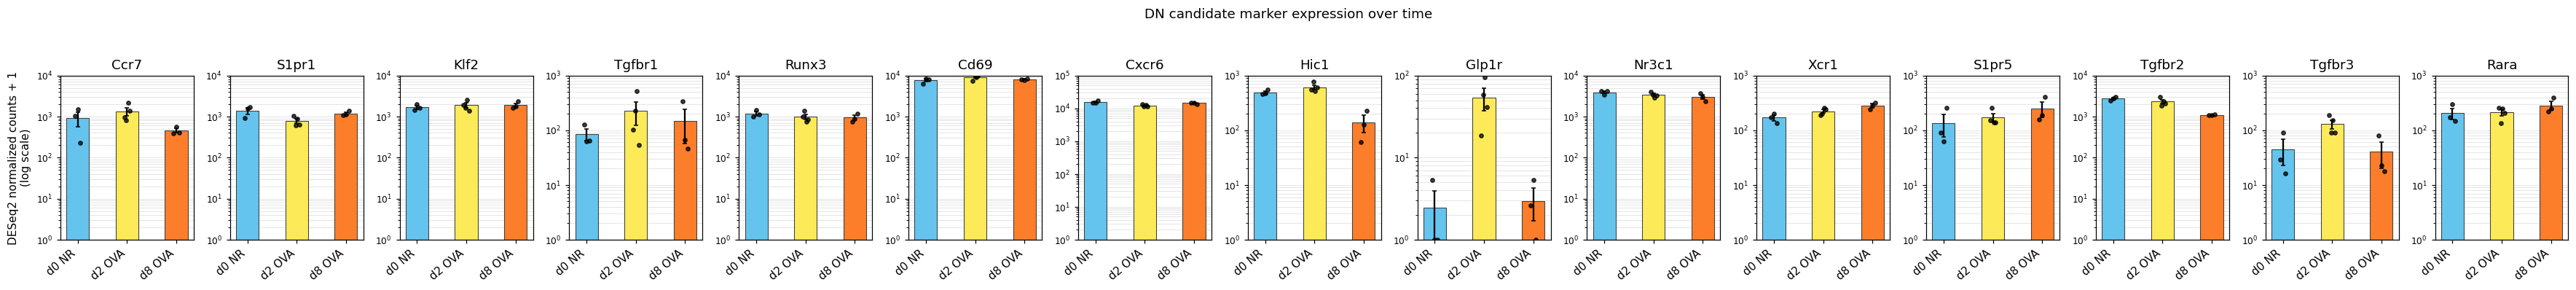

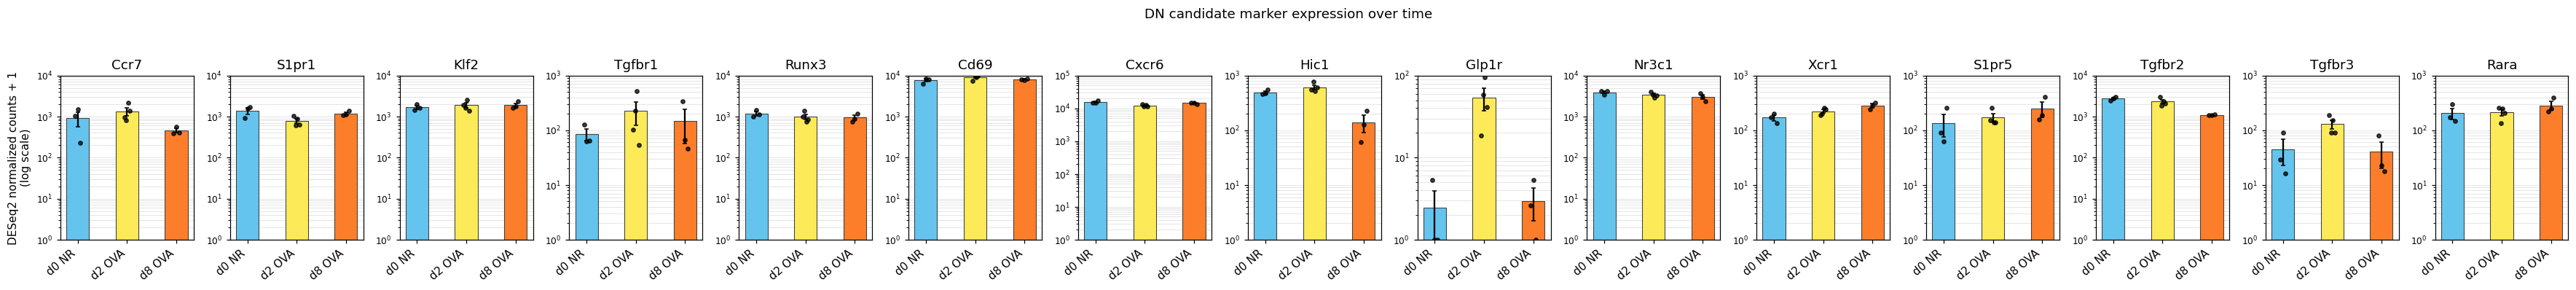

In [80]:
dn_fig = plot_population_timecourse("DN")
